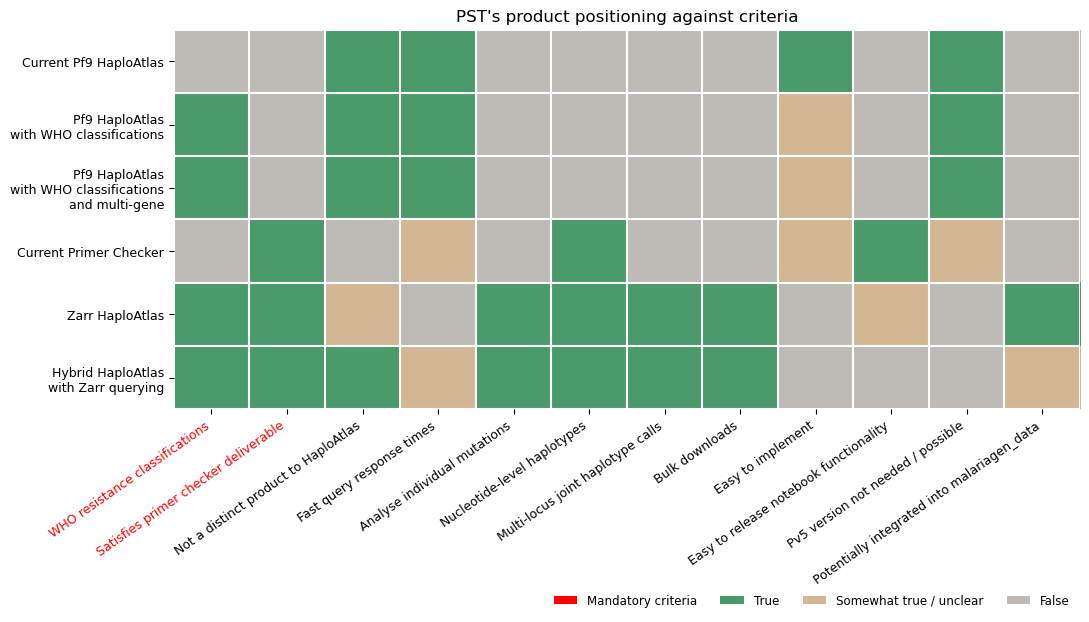

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

default_criteria = {
    "WHO resistance classifications" : 0,
    "Satisfies primer checker deliverable": 0,
    "Not a distinct product to HaploAtlas": 0,
    "Fast query response times" : 0,
    "Analyse individual mutations" : 0,
    "Nucleotide-level haplotypes" : 0,
    "Multi-locus joint haplotype calls" : 0,
    "Bulk downloads" : 0,
    "Easy to implement" : 0,
    "Easy to release notebook functionality": 0,
    "Pv5 version not needed / possible": 0,
    "Potentially integrated into malariagen_data": 0,
}

mandatory_criteria = [
    "Satisfies primer checker deliverable", "WHO resistance classifications"
]

current_pf9_haploatlas = default_criteria.copy()
current_pf9_haploatlas["Not a distinct product to HaploAtlas"] = 1
current_pf9_haploatlas["Fast query response times"] = 1
current_pf9_haploatlas["Easy to implement"] = 1
current_pf9_haploatlas["Pv5 version not needed / possible"] = 1

pf9_haploatlas_with_who = default_criteria.copy()
pf9_haploatlas_with_who["WHO resistance classifications"] = 1
pf9_haploatlas_with_who["Not a distinct product to HaploAtlas"] = 1
pf9_haploatlas_with_who["Fast query response times"] = 1
pf9_haploatlas_with_who["Easy to implement"] = 0.5
pf9_haploatlas_with_who["Pv5 version not needed / possible"] = 1

pf9_haploatlas_with_who_and_multigene = default_criteria.copy()
pf9_haploatlas_with_who_and_multigene["WHO resistance classifications"] = 1
pf9_haploatlas_with_who_and_multigene["Not a distinct product to HaploAtlas"] = 1
pf9_haploatlas_with_who_and_multigene["Fast query response times"] = 1
pf9_haploatlas_with_who_and_multigene["Easy to implement"] = 0.5
pf9_haploatlas_with_who_and_multigene["Pv5 version not needed / possible"] = 1

current_primer_checker = default_criteria.copy()
current_primer_checker["Nucleotide-level haplotypes"] = 1
current_primer_checker["Fast query response times"] = 0.5
current_primer_checker["Satisfies primer checker deliverable"] = 1
current_primer_checker["Easy to implement"] = 0.5
current_primer_checker["Easy to release notebook functionality"] = 1
current_primer_checker["Pv5 version not needed / possible"] = 0.5

zarr_haploatlas = default_criteria.copy()
zarr_haploatlas["Analyse individual mutations"] = 1
zarr_haploatlas["Nucleotide-level haplotypes"] = 1
zarr_haploatlas["WHO resistance classifications"] = 1
zarr_haploatlas["Not a distinct product to HaploAtlas"] = 0.5
zarr_haploatlas["Multi-locus joint haplotype calls"] = 1
zarr_haploatlas["Bulk downloads"] = 1
zarr_haploatlas["Satisfies primer checker deliverable"] = 1
zarr_haploatlas["Easy to release notebook functionality"] = 0.5
zarr_haploatlas["Pv5 version not needed / possible"] = 0
zarr_haploatlas["Potentially integrated into malariagen_data"] = 1

hybrid_haploatlas_with_zarr_querying = default_criteria.copy()
hybrid_haploatlas_with_zarr_querying["Not a distinct product to HaploAtlas"] = 1
hybrid_haploatlas_with_zarr_querying["Analyse individual mutations"] = 1
hybrid_haploatlas_with_zarr_querying["Nucleotide-level haplotypes"] = 1
hybrid_haploatlas_with_zarr_querying["WHO resistance classifications"] = 1
hybrid_haploatlas_with_zarr_querying["Multi-locus joint haplotype calls"] = 1
hybrid_haploatlas_with_zarr_querying["Bulk downloads"] = 1
hybrid_haploatlas_with_zarr_querying["Satisfies primer checker deliverable"] = 1
hybrid_haploatlas_with_zarr_querying["Fast query response times"] = 0.5
hybrid_haploatlas_with_zarr_querying["Potentially integrated into malariagen_data"] = 0.5
product_positioning = pd.DataFrame([
    current_pf9_haploatlas,
    pf9_haploatlas_with_who,
    pf9_haploatlas_with_who_and_multigene,
    current_primer_checker,
    zarr_haploatlas,
    hybrid_haploatlas_with_zarr_querying
], index=[
    "Current Pf9 HaploAtlas",
    "Pf9 HaploAtlas\nwith WHO classifications",
    "Pf9 HaploAtlas\nwith WHO classifications\nand multi-gene",
    "Current Primer Checker",
    "Zarr HaploAtlas",
    "Hybrid HaploAtlas\nwith Zarr querying"
])

cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom",
    [(0.0, "#BEBBB6"),
    (0.5, "#D4B896"),
    (1.0, "#4a9a6a")],
    N=256
)

fig, ax = plt.subplots(figsize=(11, 7))

ax.imshow(product_positioning.values, cmap=cmap, vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(product_positioning.columns)))
ax.set_xticklabels(product_positioning.columns, fontsize=9, ha="right", rotation=35)
for label in ax.get_xticklabels():
    if label.get_text() in mandatory_criteria:
        label.set_color("red")
ax.set_yticks(range(len(product_positioning.index)))
ax.set_yticklabels(product_positioning.index, fontsize=9)

ax.set_xticks(np.arange(-0.5, len(product_positioning.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(product_positioning.index), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="minor", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

legend_elements = [
    mpatches.Patch(facecolor="red", label="Mandatory criteria"),
    mpatches.Patch(facecolor="#4a9a6a", label="True"),
    mpatches.Patch(facecolor="#D4B896", label="Somewhat true / unclear"),
    mpatches.Patch(facecolor="#BEBBB6", label="False"),
]
ax.legend(handles=legend_elements, loc="lower right",
    bbox_to_anchor=(1, -0.55), ncol=4, frameon=False, fontsize=8.5)

plt.tight_layout()
plt.title("PST's product positioning against criteria", fontsize=12)
# plt.savefig("heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Separate category: Multi-gene requires careful consideration of displaying multiple haplotypes on upset plot